# Analisi dei dati per la previsione della *Probability of Default*
### South German Credit — regressione logistica con selezione stepwise

Questo notebook accompagna l'elaborato di Master *"Credit Risk Modeling e Data Analysis"*. L'obiettivo applicativo è
studiare quali caratteristiche del richiedente risultano associate a una diversa **probabilità stimata di default** e
valutare la capacità discriminante di un modello di **regressione logistica**. La selezione delle variabili avviene
tramite una procedura **stepwise forward basata sull'AIC**; la stima e l'inferenza del modello sono realizzate con
**statsmodels**.

Il lavoro si colloca nella tradizione del **German Credit / Statlog**, storicamente associato a Hofmann, ma utilizza la
versione corretta denominata **South German Credit**, resa disponibile successivamente per superare alcune incongruenze
presenti nella documentazione della versione precedente.

## 1. Obiettivo dell'analisi

La domanda di ricerca è: *quali caratteristiche del richiedente sono associate a una diversa probabilità stimata di
default e con quale capacità un modello logistico riesce a distinguere, su osservazioni non utilizzate nella stima, i
clienti in default da quelli regolari?*

Il percorso segue i passaggi tipici di un'analisi empirica: esplorazione e controllo dei dati, preprocessing, stima del
modello completo, selezione stepwise, stima del modello finale, interpretazione degli *odds ratio* e valutazione della
capacità discriminante. La regressione logistica resta il fulcro metodologico; il train/test split e le metriche di
classificazione sono utilizzati come strumenti di valutazione e non come base per una competizione tra algoritmi di
*machine learning*.

## 2. Ambiente e librerie

**Obiettivo:** predisporre l'ambiente di lavoro.  
**Metodo:** `pandas` e `numpy` per la gestione dei dati; `matplotlib` e `seaborn` per i grafici; **`statsmodels`** per la
stima e l'inferenza del modello; `scikit-learn` per lo split e le metriche di classificazione.  
**Motivazione:** garantire coerenza con l'impianto della tesi e riproducibilità. Gli avvisi (*warning*) non vengono
soppressi globalmente; eventuali avvisi tecnici innocui vengono gestiti solo localmente e in modo esplicito.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

print('statsmodels', statsmodels.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

statsmodels 0.14.6 | pandas 2.2.3 | numpy 2.3.5


## 3. Dataset e descrizione delle variabili

**Obiettivo:** caricare il dataset **South German Credit** e verificarne le dimensioni iniziali.  
**Metodo:** lettura del file CSV mediante `pandas.read_csv()`.  
**Motivazione:** le scelte successive devono partire dalla struttura effettiva dei dati e dal relativo codebook.

In [2]:
df = pd.read_csv('german_credit_data.csv')
print('Numero di osservazioni:', df.shape[0])
print('Numero di colonne     :', df.shape[1])
df.head()

Numero di osservazioni: 1000
Numero di colonne     : 21


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,wohnzeit,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1,1


Il dataset utilizzato è il **South German Credit**, versione corretta del classico German Credit (Statlog)
storicamente associato a Hofmann. I nomi delle variabili sono mantenuti in tedesco nel codice per preservare la
tracciabilità rispetto al dataset. La tabella seguente riporta il significato di **tutte** le variabili, così da rendere
leggibile l'analisi prima di qualunque modellazione. La variabile risposta originale è `kredit`
(1 = cliente buono, 0 = cliente cattivo).

In [3]:
codebook = {
 'laufkont':'Stato del conto corrente', 'laufzeit':'Durata del credito (mesi)',
 'moral':'Storia creditizia / puntualità passata', 'verw':'Finalità del credito',
 'hoehe':'Importo del credito (DM)', 'sparkont':'Risparmio / titoli',
 'beszeit':'Anzianità lavorativa', 'rate':'Rata come % del reddito disponibile',
 'famges':'Stato civile e sesso', 'buerge':'Altri debitori / garanti',
 'wohnzeit':'Anni di residenza attuale', 'verm':'Proprietà / bene più rilevante',
 'alter':'Età (anni)', 'weitkred':'Altri piani di rateizzazione',
 'wohn':'Regime abitativo', 'bishkred':'N. crediti in essere presso la banca',
 'beruf':'Qualifica professionale', 'pers':'N. persone a carico',
 'telef':'Intestatario di telefono', 'gastarb':'Lavoratore straniero',
 'kredit':'Rischio di credito (1 = buono, 0 = cattivo)'}
pd.DataFrame({'variabile': list(codebook), 'descrizione': list(codebook.values())})

,variabile,descrizione
0,laufkont,Stato del conto corrente
1,laufzeit,Durata del credito (mesi)
2,moral,Storia creditizia / puntualità passata
3,verw,Finalità del credito
4,hoehe,Importo del credito (DM)
5,sparkont,Risparmio / titoli
6,beszeit,Anzianità lavorativa
7,rate,Rata come % del reddito disponibile
8,famges,Stato civile e sesso
9,buerge,Altri debitori / garanti


**Obiettivo:** distinguere i tipi di variabile e definire l'evento da modellare.  
**Metodo:** durata (`laufzeit`), importo (`hoehe`) ed età (`alter`) sono trattate come **variabili quantitative
continue**. Le restanti variabili sono prevalentemente categoriali o ordinali, codificate mediante livelli discreti;
nell'analisi vengono trattate come **fattori** e successivamente trasformate mediante one-hot encoding, evitando di
imporre artificialmente una relazione lineare tra i codici numerici e il log-odds di default.

Si costruisce inoltre la variabile risposta **`default`**, pari a **1 quando il cliente è cattivo pagatore**
(`kredit = 0`) e a **0 quando è buon pagatore** (`kredit = 1`).  
**Motivazione:** nel credit risk l'evento di interesse è il default, quindi è utile che corrisponda alla classe positiva.

In [4]:
quant = ['laufzeit', 'hoehe', 'alter']
cat = [c for c in df.columns if c not in quant + ['kredit']]

df['default'] = (df['kredit'] == 0).astype(int)   # 1 = cattivo pagatore (default); 0 = buon pagatore
df['classe'] = df['default'].map({0: 'Buon pagatore', 1: 'Default'})  # etichette per i grafici

# Etichette italiane usate soltanto nella presentazione grafica.
label_it = {
 'laufkont':'Stato del conto corrente', 'laufzeit':'Durata del credito', 'moral':'Storia creditizia',
 'verw':'Finalità del credito', 'hoehe':'Importo del credito', 'sparkont':'Risparmio',
 'beszeit':'Anzianità lavorativa', 'rate':'Rata (% del reddito)', 'famges':'Stato civile / sesso',
 'buerge':'Garanti / altri debitori', 'wohnzeit':'Anni di residenza', 'verm':'Proprietà / beni', 'alter':'Età',
 'weitkred':'Altri piani di rateizzazione', 'wohn':'Regime abitativo', 'bishkred':'N. crediti in essere',
 'beruf':'Qualifica professionale', 'pers':'Persone a carico', 'telef':'Telefono intestato',
 'gastarb':'Lavoratore straniero'
}

print('Variabili quantitative (%d):' % len(quant), quant)
print('Variabili trattate come fattori (%d):' % len(cat))
print('   ', cat)
print('Codifica target -> default=1: cattivo pagatore | default=0: buon pagatore')
print('Proporzione di bad credit nel campione: %.1f%%' % (df['default'].mean()*100))

Variabili quantitative (3): ['laufzeit', 'hoehe', 'alter']
Variabili trattate come fattori (17):
    ['laufkont', 'moral', 'verw', 'sparkont', 'beszeit', 'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'weitkred', 'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb']
Codifica target -> default=1: cattivo pagatore | default=0: buon pagatore
Proporzione di bad credit nel campione: 30.0%


## 4. Controlli iniziali e struttura dei dati
**Obiettivo:** conoscere tipi di dato e ordini di grandezza. **Metodo:** `info()` e statistiche descrittive delle
variabili quantitative. **Motivazione:** base per i controlli di qualità e per il preprocessing.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   laufkont  1000 non-null   int64 
 1   laufzeit  1000 non-null   int64 
 2   moral     1000 non-null   int64 
 3   verw      1000 non-null   int64 
 4   hoehe     1000 non-null   int64 
 5   sparkont  1000 non-null   int64 
 6   beszeit   1000 non-null   int64 
 7   rate      1000 non-null   int64 
 8   famges    1000 non-null   int64 
 9   buerge    1000 non-null   int64 
 10  wohnzeit  1000 non-null   int64 
 11  verm      1000 non-null   int64 
 12  alter     1000 non-null   int64 
 13  weitkred  1000 non-null   int64 
 14  wohn      1000 non-null   int64 
 15  bishkred  1000 non-null   int64 
 16  beruf     1000 non-null   int64 
 17  pers      1000 non-null   int64 
 18  telef     1000 non-null   int64 
 19  gastarb   1000 non-null   int64 
 20  kredit    1000 non-null   int64 
 21  default   1000 

In [6]:
df[quant].describe().round(2)

,laufzeit,hoehe,alter
count,1000.00,1000.00,1000.00
mean,20.90,3271.25,35.54
std,12.06,2822.75,11.35
min,4.00,250.00,19.00
25%,12.00,1365.50,27.00
50%,18.00,2319.50,33.00
75%,24.00,3972.25,42.00
max,72.00,18424.00,75.00


## 5. Controlli di qualità dei dati

**Obiettivo:** verificare la presenza di valori mancanti, righe duplicate e la cardinalità delle variabili categoriali
e ordinali trattate come fattori.  
**Metodo:** conteggi diretti mediante `isna()`, `duplicated()` e `nunique()`.  
**Motivazione:** eventuali interventi di pulizia devono essere motivati dai dati effettivamente osservati.

In [7]:
print('Valori mancanti totali :', int(df.isna().sum().sum()))
print('Righe duplicate        :', int(df.duplicated().sum()))
card = pd.DataFrame({'variabile': [label_it[c] for c in cat],
                     'codice': cat,
                     'n_livelli': [df[c].nunique() for c in cat]})
card

Valori mancanti totali : 0
Righe duplicate        : 0


,variabile,codice,n_livelli
0,Stato del conto corrente,laufkont,4
1,Storia creditizia,moral,5
2,Finalità del credito,verw,10
3,Risparmio,sparkont,5
4,Anzianità lavorativa,beszeit,5
5,Rata (% del reddito),rate,4
6,Stato civile / sesso,famges,4
7,Garanti / altri debitori,buerge,3
8,Anni di residenza,wohnzeit,4
9,Proprietà / beni,verm,4


Il controllo mostra **zero valori mancanti e zero duplicati**: sono quindi stati verificati e non è stato necessario
rimuovere o imputare alcuna osservazione. Le variabili categoriali e ordinali presentano in genere una cardinalità
contenuta; la finalità del credito (`verw`) è più granulare rispetto alle altre.

## 6. Analisi della variabile target

**Obiettivo:** valutare la distribuzione della variabile dipendente `default`.  
**Metodo:** conteggio delle frequenze assolute e relative e rappresentazione tramite grafico a barre.  
**Motivazione:** la composizione delle classi influenza l'interpretazione delle metriche di classificazione e suggerisce
di affiancare all'accuracy misure come recall, precision, specificità e AUC.

default
Buon pagatore (0)    700
Default (1)          300
Name: count, dtype: int64


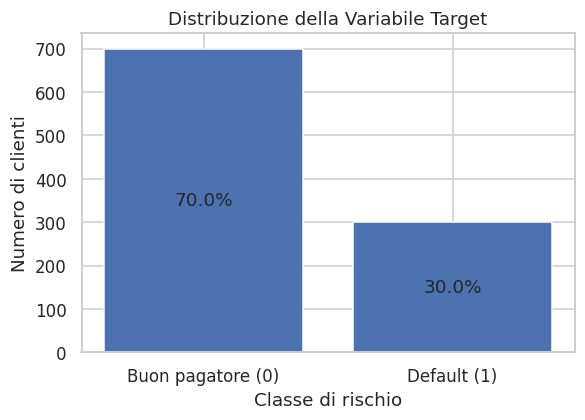

In [8]:
counts = df['default'].value_counts().sort_index()
print(counts.rename({0: 'Buon pagatore (0)', 1: 'Default (1)'}))

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['Buon pagatore (0)', 'Default (1)'], counts.values)

ax.set_title('Distribuzione della Variabile Target')
ax.set_xlabel('Classe di rischio')
ax.set_ylabel('Numero di clienti')

total = len(df)
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value/2,
            f'{100*value/total:.1f}%',
            ha='center', va='center')

plt.tight_layout()
plt.show()

Le due classi sono in rapporto di circa **70% buoni / 30% bad credit**: uno sbilanciamento moderato, non estremo.
Per questo motivo la valutazione non si limita all'*accuracy*, ma considera anche **recall**, **precision**,
**specificità** e **AUC**. La proporzione del 30% osservata descrive la composizione del campione analizzato e non deve
essere interpretata come il tasso di default di una popolazione bancaria reale.

## 7. Analisi delle variabili quantitative

**Obiettivo:** esaminare distribuzione e relazione descrittiva con il default.  
**Metodo:** istogrammi per classe, utili per forma e asimmetria delle distribuzioni, e boxplot per classe, utili per il
confronto tra gruppi e l'individuazione di valori estremi. I due grafici svolgono quindi funzioni complementari.  
**Motivazione:** verificare se durata, importo ed età mostrano differenze apprezzabili tra clienti in default e
non-default prima della modellazione multivariata.

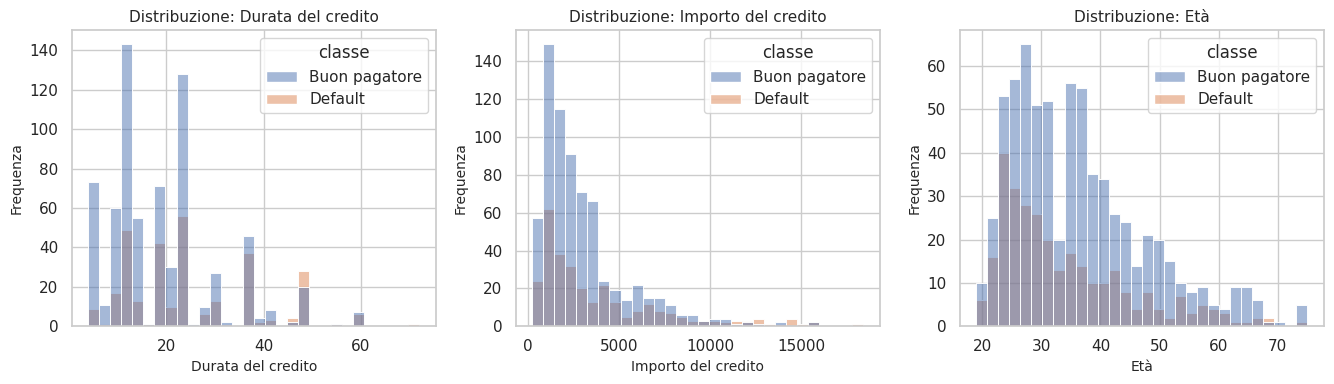

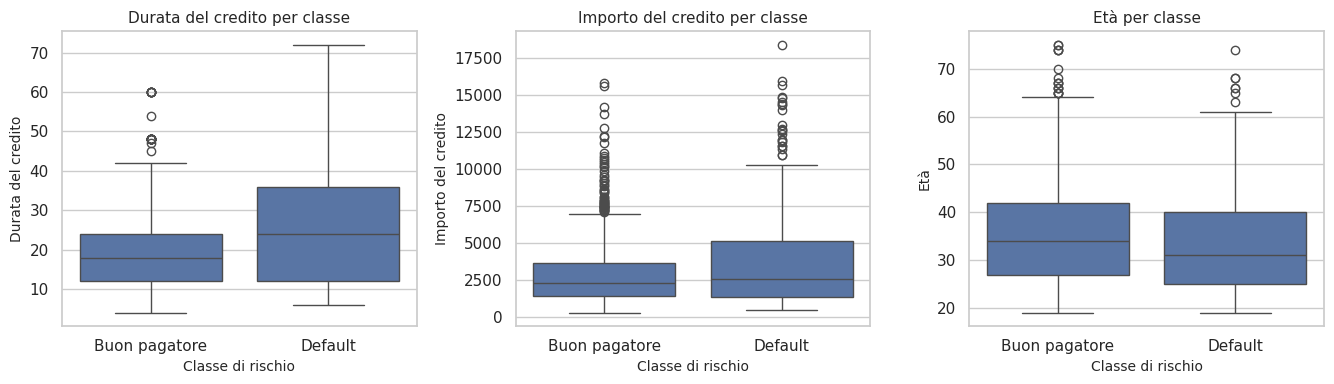

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
for i, v in enumerate(quant):
    sns.histplot(data=df, x=v, hue='classe', bins=30, ax=ax[i])
    ax[i].set_title('Distribuzione: ' + label_it[v])
    ax[i].set_xlabel(label_it[v])
    ax[i].set_ylabel('Frequenza')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
for i, v in enumerate(quant):
    # Seaborn 0.13 può generare un PendingDeprecationWarning interno di Matplotlib
    # relativo al parametro "vert": viene filtrato soltanto in questo blocco grafico.
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=PendingDeprecationWarning,
                                message='vert: bool will be deprecated.*')
        sns.boxplot(x='classe', y=v, data=df, ax=ax[i])
    ax[i].set_title(label_it[v] + ' per classe')
    ax[i].set_xlabel('Classe di rischio')
    ax[i].set_ylabel(label_it[v])
plt.tight_layout()
plt.show()

Durata e importo del credito tendono a essere **mediamente più elevati tra i clienti in default**, mentre per l'età
la differenza tra i due gruppi appare più contenuta. Le distribuzioni di durata e importo risultano asimmetriche verso
destra. Queste osservazioni hanno natura esplorativa: la loro associazione con il default viene successivamente valutata
nel modello multivariato.

## 8. Variabili categoriali/ordinali e tasso di default

**Obiettivo:** osservare se alcune modalità si associano descrittivamente a un diverso tasso di default.  
**Metodo:** calcolo del tasso di default per modalità per alcune variabili selezionate a scopo illustrativo.  
**Motivazione:** vengono mostrate stato del conto corrente, storia creditizia e disponibilità di risparmio perché sono
variabili economicamente interpretabili e pertinenti al credit scoring; la valutazione complessiva di tutti i regressori
è comunque demandata al modello e alla procedura di selezione.

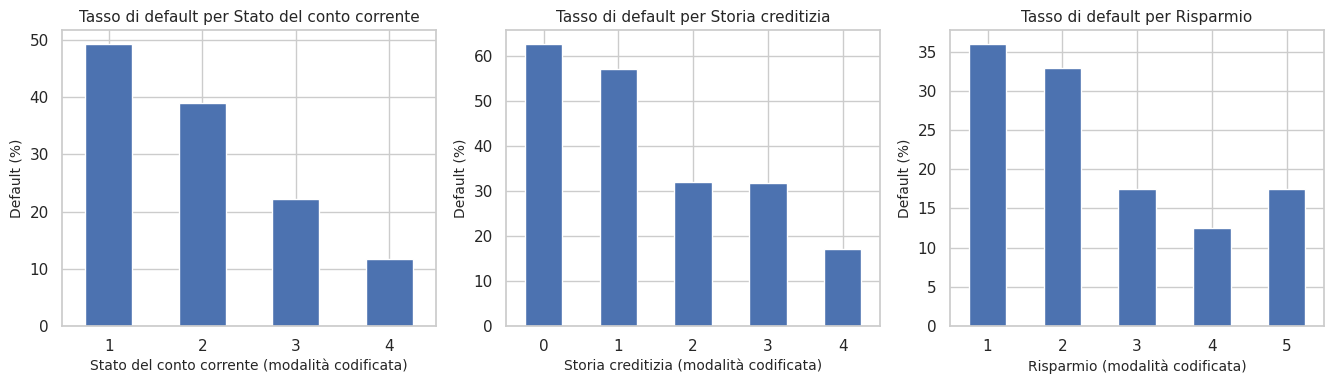

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
for i, v in enumerate(['laufkont', 'moral', 'sparkont']):
    rate_default = (df.groupby(v)['default'].mean() * 100)
    rate_default.plot(kind='bar', ax=ax[i])
    ax[i].set_title('Tasso di default per ' + label_it[v])
    ax[i].set_xlabel(label_it[v] + ' (modalità codificata)')
    ax[i].set_ylabel('Default (%)')
    ax[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Per le variabili illustrate il tasso di default cambia sensibilmente tra le modalità. In particolare, livelli
associati a una migliore situazione del conto corrente, a una storia creditizia più favorevole e a una maggiore
disponibilità di risparmio mostrano, in termini descrittivi, tassi di default inferiori. Si tratta di **associazioni
esplorative** e di variabili potenzialmente rilevanti per il modello; la loro effettiva inclusione dipende dalla
selezione multivariata.

## 9. Correlazione e multicollinearità

**Obiettivo:** valutare la ridondanza tra i regressori quantitativi.  
**Metodo:** matrice di correlazione di Pearson tra le variabili quantitative (con il target mostrato a fini descrittivi)
e calcolo del **Variance Inflation Factor (VIF)** sulle sole variabili quantitative, includendo l'intercetta nel calcolo.  
**Motivazione:** una forte multicollinearità può gonfiare gli errori standard e rendere instabili i coefficienti.

Il VIF riportato qui riguarda quindi **solo le tre variabili quantitative** e non consente, da solo, di concludere che
l'intera matrice di 54 regressori sia priva di collinearità.

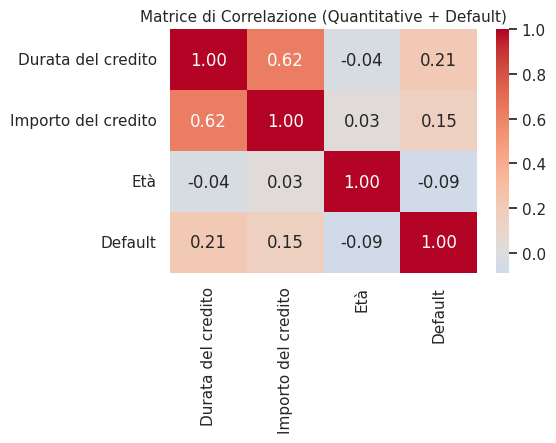

,Variabile,VIF
0,Durata del credito,1.650
1,Importo del credito,1.649
2,Età,1.007


In [11]:
corr = df[quant + ['default']].corr()
corr.index = [label_it.get(c, 'Default') for c in corr.index]
corr.columns = [label_it.get(c, 'Default') for c in corr.columns]

plt.figure(figsize=(5.8, 4.6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice di Correlazione (Quantitative + Default)')
plt.tight_layout()
plt.show()

# VIF con intercetta: il calcolo è limitato alle sole variabili quantitative.
Xv = sm.add_constant(df[quant])
vif = pd.DataFrame({
    'Variabile': [label_it[c] for c in quant],
    'VIF': [variance_inflation_factor(Xv.values, i+1) for i in range(len(quant))]
})
vif.round(3)

Le correlazioni tra le variabili quantitative sono modeste e i **VIF sono prossimi a 1**: non emerge
multicollinearità problematica tra i tre regressori continui. Questo risultato non va esteso automaticamente a tutte le
dummy create successivamente.

L'opzione `drop_first=True` elimina invece la dipendenza lineare perfetta tra tutte le modalità di una stessa variabile
e l'intercetta, omettendo una categoria di riferimento (*dummy variable trap*). Si tratta di un aspetto della codifica:
il controllo della multicollinearità e la selezione stepwise restano concetti distinti.

## 10. Preprocessing e codifica delle variabili

**Obiettivo:** costruire la matrice dei regressori.  
**Metodo:** le variabili trattate come fattori vengono rappresentate tramite **indicatori binari 0/1**
(*one-hot encoding*) con `drop_first=True`; le quantitative restano numeriche.  
**Motivazione:** i codici discreti del codebook non vengono interpretati come quantità continue. Per ogni fattore una
modalità è omessa e funge da **categoria di riferimento**, rispetto alla quale sono letti i coefficienti delle dummy.

In [12]:
X = pd.get_dummies(df[quant + cat], columns=cat, drop_first=True).astype(float)
y = df['default'].values
print('Matrice dei regressori:', X.shape)
print('Numero di regressori dopo la codifica:', X.shape[1])

Matrice dei regressori: (1000, 54)
Numero di regressori dopo la codifica: 54


## 11. Suddivisione train/test e standardizzazione

**Obiettivo:** separare la fase di stima da quella di valutazione.  
**Metodo:** split stratificato 70/30 con `random_state=42`; le sole variabili quantitative vengono standardizzate usando
media e deviazione standard calcolate **esclusivamente sul training set** e poi applicate al test set.  
**Motivazione:** il modello viene stimato su 700 osservazioni e valutato sulle 300 tenute fuori dalla stima, evitando
*data leakage*. Grazie a `stratify=y`, training e test contengono entrambi buoni e cattivi pagatori mantenendo
approssimativamente la stessa proporzione delle classi.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Copie esplicite per rendere le trasformazioni successive non ambigue.
X_train = X_train.copy()
X_test = X_test.copy()

mu, sigma = X_train[quant].mean(), X_train[quant].std()
X_train[quant] = (X_train[quant] - mu) / sigma
X_test[quant]  = (X_test[quant]  - mu) / sigma

print('Training set:', X_train.shape, '| default %.1f%%' % (y_train.mean()*100))
print('Test set    :', X_test.shape,  '| default %.1f%%' % (y_test.mean()*100))
print('Eventi (default) nel training: %d | regressori: %d | eventi per regressore: %.1f'
      % (int(y_train.sum()), X_train.shape[1], y_train.sum()/X_train.shape[1]))

Training set: (700, 54) | default 30.0%
Test set    : (300, 54) | default 30.0%
Eventi (default) nel training: 210 | regressori: 54 | eventi per regressore: 3.9


Nel training si contano **210 eventi di default** a fronte di 54 regressori candidati, cioè circa
**3,9 eventi per regressore**. Il valore segnala una complessità relativamente elevata del modello completo rispetto
agli eventi disponibili e costituisce una motivazione per valutare una specificazione più parsimoniosa; non rappresenta
una soglia assoluta né dimostra automaticamente la presenza di *overfitting*.

## 12. Modello logistico completo
**Obiettivo:** stimare un modello di partenza con tutti i regressori. **Metodo:** `sm.Logit` (massima verosimiglianza) sul
training. **Motivazione:** costituisce il termine di paragone rispetto al modello selezionato e fornisce l'output
inferenziale completo.

In [14]:
X_train_c = sm.add_constant(X_train)
full_model = sm.Logit(y_train, X_train_c).fit(method='bfgs', maxiter=1000, disp=0)
print(full_model.summary())
print('\nAIC: %.1f | BIC: %.1f | Pseudo R2 (McFadden): %.3f'
      % (full_model.aic, full_model.bic, full_model.prsquared))

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  700
Model:                          Logit   Df Residuals:                      645
Method:                           MLE   Df Model:                           54
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                  0.3173
Time:                        14:44:08   Log-Likelihood:                -291.91
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 1.004e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8450      1.401     -0.603      0.546      -3.591       1.901
laufzeit       0.3080      0.142      2.170      0.030       0.030       0.586
hoehe          0.4772      0.161      2.970      0.0

Nel modello completo numerosi coefficienti presentano p-value elevati e il rapporto tra eventi e regressori è
contenuto. Queste evidenze motivano l'applicazione di una procedura di selezione finalizzata a ottenere una
specificazione più parsimoniosa, senza assumere a priori che la selezione debba necessariamente migliorare ogni aspetto
del modello.

## 13. Selezione stepwise (forward, criterio AIC)

**Obiettivo:** individuare un sottoinsieme di regressori con un buon compromesso tra adattamento e complessità.  
**Metodo:** procedura **forward** basata sull'**AIC**. Si parte dal modello nullo (sola intercetta); a ogni iterazione si
valuta l'aggiunta di ciascuno dei regressori ancora esclusi e si inserisce quello che produce la maggiore riduzione
dell'AIC; la procedura termina quando nessuna ulteriore aggiunta riduce l'AIC.  
**Motivazione:** l'AIC bilancia bontà di adattamento e numero di parametri. Le variabili incluse derivano
dall'algoritmo eseguito sui dati e non sono state decise in anticipo.

In questa versione la procedura opera sulle **singole colonne indicatore** prodotte dall'encoding, partendo da 54
regressori candidati. Di conseguenza, livelli diversi della stessa variabile originaria possono essere selezionati
separatamente: questa scelta viene tenuta presente nell'interpretazione del modello finale.

Durante la ricerca vengono stimati molti modelli candidati. Gli eventuali warning e i problemi di convergenza vengono
**registrati e controllati**, anziché essere soppressi globalmente.

In [15]:
def fit_logit(cols):
    X_fit = sm.add_constant(X_train[cols], has_constant='add')
    with warnings.catch_warnings(record=True) as warning_log:
        warnings.simplefilter('always')
        result = sm.Logit(y_train, X_fit).fit(method='lbfgs', maxiter=200, disp=0)
    converged = bool(result.mle_retvals.get('converged', True))
    return result, warning_log, converged

null_model = sm.Logit(y_train, np.ones((len(y_train), 1))).fit(disp=0)
best_aic = null_model.aic
selected, remaining, path = [], list(X_train.columns), []
candidate_warnings, fit_issues = [], []

iteration = 0
while remaining:
    iteration += 1
    trials = []

    for c in remaining:
        try:
            model_c, warning_log, converged = fit_logit(selected + [c])

            if warning_log:
                candidate_warnings.extend([
                    (iteration, c, type(w.message).__name__, str(w.message))
                    for w in warning_log
                ])

            if not converged:
                fit_issues.append((iteration, c, 'mancata convergenza'))
                continue

            trials.append((model_c.aic, c))

        except Exception as exc:
            fit_issues.append((iteration, c, f'{type(exc).__name__}: {exc}'))

    trials.sort()

    if trials and trials[0][0] < best_aic - 1e-6:
        best_aic, add = trials[0]
        selected.append(add)
        remaining.remove(add)
        path.append((add, best_aic))
    else:
        break

print('AIC modello nullo    : %.2f' % null_model.aic)
print('Variabili selezionate: %d su %d' % (len(selected), X.shape[1]))
print('AIC modello finale   : %.2f' % best_aic)
print('Fit candidati con problemi di convergenza/errore:', len(fit_issues))
print('Warning registrati durante i fit candidati      :', len(candidate_warnings))

if candidate_warnings:
    warning_summary = (pd.DataFrame(candidate_warnings,
                                    columns=['iterazione', 'variabile', 'tipo_warning', 'messaggio'])
                       [['tipo_warning', 'messaggio']]
                       .drop_duplicates())
    display(warning_summary.head())

pd.DataFrame(path, columns=['variabile_aggiunta', 'AIC']).round(2)

AIC modello nullo    : 857.21
Variabili selezionate: 28 su 54
AIC modello finale   : 660.44
Fit candidati con problemi di convergenza/errore: 0
Warning registrati durante i fit candidati      : 0


,variabile_aggiunta,AIC
0,laufkont_4,783.08
1,laufzeit,760.60
2,moral_4,743.76
3,verw_1,734.81
4,verw_3,724.50
5,sparkont_5,716.93
6,famges_2,709.64
7,laufkont_3,702.23
8,beszeit_4,695.13
9,verm_4,690.56


La procedura riduce l'AIC in modo **monotono**, dal valore del modello nullo (circa 857,2) a quello del
modello selezionato (circa 660,4), includendo **28 regressori** sui 54 candidati. L'elenco completo delle dummy
selezionate e il relativo percorso dell'AIC sono riportati nell'output precedente.

La selezione avviene a livello di singola dummy: l'esclusione di un livello non implica che l'intera variabile originaria
sia irrilevante, ma soltanto che quel regressore non è stato aggiunto dalla procedura in questa specificazione.

## 14. Modello logistico finale
**Obiettivo:** stimare il modello sulle sole variabili selezionate. **Metodo:** refit di `sm.Logit`. **Motivazione:** è
il modello che viene poi interpretato e valutato.

In [16]:
final_model = sm.Logit(y_train, sm.add_constant(X_train[selected])).fit(method='bfgs', maxiter=1000, disp=0)
print(final_model.summary())
print('\nLog-Likelihood: %.2f | LL-Null: %.2f | LLR p-value: %.2e'
      % (final_model.llf, final_model.llnull, final_model.llr_pvalue))
print('AIC: %.1f | BIC: %.1f | Pseudo R2 (McFadden): %.3f'
      % (final_model.aic, final_model.bic, final_model.prsquared))
sig_vars = [s for s in final_model.pvalues[final_model.pvalues < 0.05].index if s != 'const']
print('Coefficienti con p-value nominale < 0.05: %d' % len(sig_vars))

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  700
Model:                          Logit   Df Residuals:                      671
Method:                           MLE   Df Model:                           28
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                  0.2956
Time:                        14:44:17   Log-Likelihood:                -301.22
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 4.851e-38
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4149      0.933      0.445      0.656      -1.413       2.243
laufkont_4    -1.8010      0.272     -6.614      0.000      -2.335      -1.267
laufzeit       0.3104      0.130      2.389      0.0

Nel modello selezionato, **19 coefficienti** presentano un p-value nominale inferiore a 0,05. Tale evidenza va
interpretata con cautela: la specificazione finale deriva da una procedura *data-driven* di selezione applicata agli
stessi dati utilizzati per la stima. I p-value e gli intervalli di confidenza riportati da `statsmodels` sono quindi
informazioni descrittive/inferenziali **condizionate al modello selezionato**, e non test confermativi su una
specificazione fissata *a priori*.

## 15. Odds ratio e interpretazione

**Obiettivo:** tradurre i coefficienti del modello in una scala più immediata.  
**Metodo:** calcolo degli *odds ratio* come esponenziale dei coefficienti, con intervalli di confidenza al 95%.  
**Motivazione:** gli OR consentono di esprimere l'associazione tra un regressore e gli odds di default mantenendo
esplicito il confronto con la categoria di riferimento o, per le quantitative standardizzate, con un incremento di una
deviazione standard.

In [17]:
ci = final_model.conf_int()
or_table = pd.DataFrame({
    'coef': final_model.params,
    'std_err': final_model.bse,
    'p_value': final_model.pvalues,
    'OR': np.exp(final_model.params),
    'OR_2.5%': np.exp(ci[0]),
    'OR_97.5%': np.exp(ci[1])}).round(4)
or_table.sort_values('OR')

,coef,std_err,p_value,OR,OR_2.5%,OR_97.5%
verw_1,-2.1442,0.4485,0.0000,0.1172,0.0486,0.2822
moral_4,-2.0268,0.4407,0.0000,0.1318,0.0555,0.3125
laufkont_4,-1.8010,0.2723,0.0000,0.1651,0.0968,0.2816
verw_8,-1.7636,1.2413,0.1554,0.1714,0.0150,1.9530
verw_10,-1.6779,0.9813,0.0873,0.1868,0.0273,1.2783
moral_3,-1.5794,0.4940,0.0014,0.2061,0.0783,0.5427
sparkont_4,-1.4588,0.6455,0.0238,0.2325,0.0656,0.8238
laufkont_3,-1.3910,0.4708,0.0031,0.2488,0.0989,0.6261
buerge_3,-1.2674,0.5974,0.0339,0.2816,0.0873,0.9080
sparkont_5,-0.9658,0.3157,0.0022,0.3807,0.2051,0.7067


L'interpretazione va intesa **a parità delle altre variabili incluse nel modello**. Un **OR > 1** è associato a odds
di default maggiori e un **OR < 1** a odds minori. Per le variabili indicatore il confronto è rispetto alla modalità di
riferimento; per durata, importo ed età, che sono state standardizzate, l'OR si riferisce a un incremento di **una
deviazione standard**.

Nel modello selezionato, alcune modalità relative allo stato del conto corrente, alla storia creditizia e al risparmio
presentano OR inferiori a 1 rispetto alle rispettive categorie di riferimento, mentre durata e importo del credito
mostrano coefficienti positivi. Anche una delle modalità della variabile relativa alla rata (`rate_4`) presenta un OR
superiore a 1. Gli intervalli di confidenza molto ampi, soprattutto per modalità poco frequenti, richiedono cautela
nell'interpretazione. Le associazioni osservate non hanno significato causale.

## 16. Confronto tra modello completo e modello finale

**Obiettivo:** verificare l'effetto della selezione.  
**Metodo:** confronto per numero di regressori, AIC, pseudo-R² di McFadden e AUC sul test set.  
**Motivazione:** valutare se la specificazione più parsimoniosa mantiene una capacità discriminante comparabile al
modello completo.

In [18]:
proba_full  = full_model.predict(sm.add_constant(X_test, has_constant='add'))
proba_test  = final_model.predict(sm.add_constant(X_test[selected], has_constant='add'))
auc = roc_auc_score(y_test, proba_test)
auc_full = roc_auc_score(y_test, proba_full)
confronto = pd.DataFrame({
    'modello': ['completo', 'finale (stepwise)'],
    'n_regressori': [X.shape[1], len(selected)],
    'AIC': [full_model.aic, final_model.aic],
    'pseudo_R2': [full_model.prsquared, final_model.prsquared],
    'AUC_test': [auc_full, auc]}).round(3)
confronto

,modello,n_regressori,AIC,pseudo_R2,AUC_test
0,completo,54,693.825,0.317,0.742
1,finale (stepwise),28,660.438,0.296,0.747


Il modello finale riduce il numero di regressori da 54 a 28 e presenta un AIC inferiore sul training set
(**circa 660,4 contro 693,8** del modello completo). Sul test set considerato mantiene una capacità discriminante
sostanzialmente equivalente e lievemente superiore (**AUC circa 0,747 contro 0,742**). Il confronto supporta quindi la
scelta di una specificazione più parsimoniosa senza suggerire che la selezione migliori necessariamente ogni metrica.

## 17. Confusion matrix e metriche di classificazione

**Obiettivo:** valutare le prestazioni di classificazione alla soglia convenzionale di 0,5.  
**Metodo:** matrice di confusione e calcolo di accuracy, precision, recall, specificità e F1 sul test set.  
**Motivazione:** l'accuracy, da sola, non descrive in modo sufficiente gli errori sulle due classi.

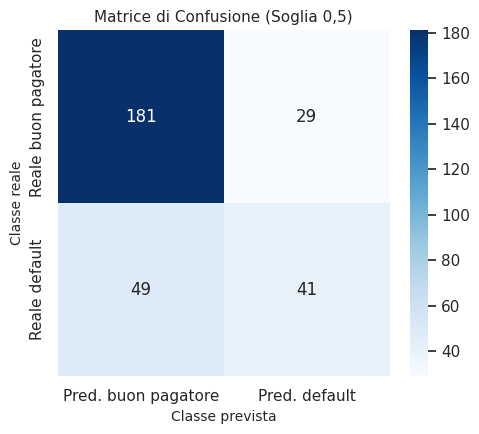

accuracy     0.740
precision    0.586
recall       0.456
specificity  0.862
f1           0.512


In [19]:
pred_05 = (proba_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_05)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. buon pagatore', 'Pred. default'],
            yticklabels=['Reale buon pagatore', 'Reale default'])
plt.title('Matrice di Confusione (Soglia 0,5)')
plt.ylabel('Classe reale')
plt.xlabel('Classe prevista')
plt.tight_layout()
plt.show()

met05 = dict(accuracy=accuracy_score(y_test, pred_05),
             precision=precision_score(y_test, pred_05),
             recall=recall_score(y_test, pred_05),
             specificity=tn/(tn+fp),
             f1=f1_score(y_test, pred_05))

for k, v in met05.items():
    print('%-12s %.3f' % (k, v))

La **recall della classe default** misura la quota dei veri default correttamente identificati dal modello. Una recall
contenuta significa che una parte dei clienti realmente in default viene classificata come buon pagatore, generando
**falsi negativi**. Nel credit risk il costo di questi errori può essere particolarmente rilevante, ma il loro peso
relativo rispetto ai falsi positivi dipende dal contesto decisionale, dalla perdita attesa e dalle politiche di rischio.

## 18. Curva ROC e AUC

**Obiettivo:** valutare la capacità discriminante indipendentemente dalla scelta di una singola soglia.  
**Metodo:** curva ROC e area sottesa (AUC) sul test set.  
**Motivazione:** l'AUC fornisce una misura sintetica della capacità di ordinare i soggetti secondo il rischio stimato.

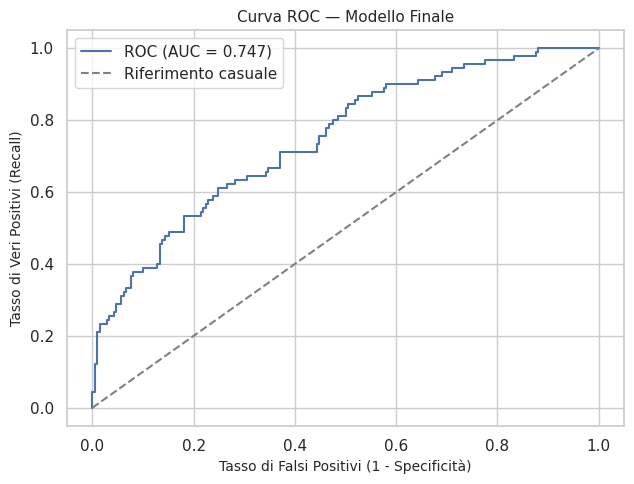

AUC test: 0.747


In [20]:
fpr, tpr, thr = roc_curve(y_test, proba_test)

plt.figure(figsize=(6.5, 5))
plt.plot(fpr, tpr, label='ROC (AUC = %.3f)' % auc)
plt.plot([0, 1], [0, 1], '--', color='grey', label='Riferimento casuale')
plt.xlabel('Tasso di Falsi Positivi (1 - Specificità)')
plt.ylabel('Tasso di Veri Positivi (Recall)')
plt.title('Curva ROC — Modello Finale')
plt.legend()
plt.tight_layout()
plt.show()

print('AUC test: %.3f' % auc)

L'AUC sintetizza la capacità discriminante del modello tra clienti in default e non in default indipendentemente
dalla scelta di una specifica soglia. In termini probabilistici, un'AUC di circa **0,747** indica che, scegliendo
casualmente un soggetto in default e uno non in default, il modello assegna al primo un rischio stimato maggiore in circa
il **74,7%** delle coppie.

## 19. Scelta della soglia di classificazione

**Obiettivo:** esaminare il *trade-off* tra sensibilità e specificità per soglie alternative a 0,5.  
**Metodo:** calcolo delle metriche al variare del cut-off e individuazione della soglia secondo il criterio di
**Youden** (massimo TPR − FPR).  
**Motivazione:** la soglia 0,5 è convenzionale e non necessariamente adeguata a ogni decisione creditizia.

In questo notebook il criterio di Youden viene calcolato **sullo stesso test set esclusivamente a titolo
illustrativo/descrittivo**. Di conseguenza, le metriche riportate alla soglia così individuata non costituiscono una
valutazione indipendente della soglia scelta. In un'applicazione operativa, il cut-off dovrebbe essere determinato su
dati di sviluppo/validazione e poi valutato su un campione indipendente, tenendo inoltre conto dei costi economici dei
falsi positivi e dei falsi negativi e delle politiche di rischio.

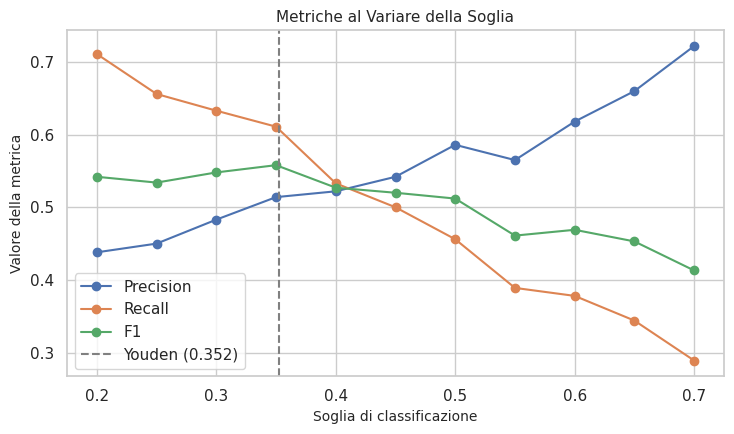

Soglia individuata secondo il criterio di Youden: 0.352


,Metrica,"Soglia 0,5",Soglia Youden (illustrativa)
0,Soglia,0.500,0.352
1,Accuracy,0.740,0.710
2,Precision,0.586,0.514
3,Recall,0.456,0.611
4,Specificità,0.862,0.752
5,F1,0.512,0.558


In [21]:
rows = []
for t in np.round(np.arange(0.20, 0.71, 0.05), 2):
    p = (proba_test >= t).astype(int)
    tn2, fp2, fn2, tp2 = confusion_matrix(y_test, p).ravel()
    rows.append([t,
                 accuracy_score(y_test, p),
                 precision_score(y_test, p, zero_division=0),
                 recall_score(y_test, p),
                 tn2/(tn2+fp2),
                 f1_score(y_test, p)])

soglie = pd.DataFrame(
    rows,
    columns=['Soglia', 'Accuracy', 'Precision', 'Recall', 'Specificità', 'F1']
).round(3)

youden = float(thr[np.argmax(tpr - fpr)])
p_you = (proba_test >= youden).astype(int)
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, p_you).ravel()

metyou = dict(
    accuracy=accuracy_score(y_test, p_you),
    precision=precision_score(y_test, p_you),
    recall=recall_score(y_test, p_you),
    specificity=tn3/(tn3+fp3),
    f1=f1_score(y_test, p_you)
)

plt.figure(figsize=(7.5, 4.5))
for col in ['Precision', 'Recall', 'F1']:
    plt.plot(soglie['Soglia'], soglie[col], marker='o', label=col)
plt.axvline(youden, ls='--', color='grey', label='Youden (%.3f)' % youden)
plt.xlabel('Soglia di classificazione')
plt.ylabel('Valore della metrica')
plt.legend()
plt.title('Metriche al Variare della Soglia')
plt.tight_layout()
plt.show()

print('Soglia individuata secondo il criterio di Youden: %.3f' % youden)

confronto_soglie = pd.DataFrame({
    'Metrica': ['Soglia', 'Accuracy', 'Precision', 'Recall', 'Specificità', 'F1'],
    'Soglia 0,5': [0.5, met05['accuracy'], met05['precision'], met05['recall'],
                   met05['specificity'], met05['f1']],
    'Soglia Youden (illustrativa)': [youden, metyou['accuracy'], metyou['precision'],
                                     metyou['recall'], metyou['specificity'], metyou['f1']]
}).round(3)

confronto_soglie

L'analisi illustrativa evidenzia il *trade-off*: abbassando la soglia rispetto a 0,5 aumenta la recall dei default
(si intercettano più cattivi pagatori), ma aumentano anche i falsi positivi, con conseguente riduzione della specificità
e, in questo caso, della precision. La soglia individuata con Youden sul test set non viene presentata come soglia
“ottimale” né come risultato validato: serve soltanto a mostrare come cambia il compromesso tra i due tipi di errore.

## 20. Probability of Default stimata

**Obiettivo:** rappresentare la regressione logistica come stima probabilistica del default.  
**Metodo:** distribuzione delle probabilità stimate sul test set, separatamente per classe reale.  
**Motivazione:** osservare quanto le distribuzioni dei due gruppi risultino separate e dove si concentrino i casi più
difficili da distinguere.

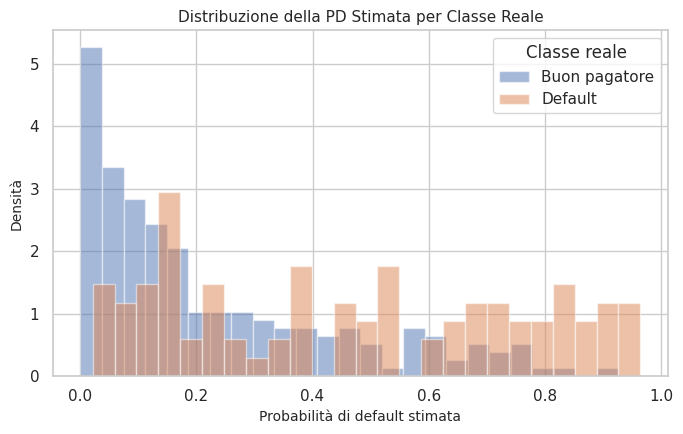

PD media stimata — buoni: 0.226 | default: 0.466


In [22]:
plt.figure(figsize=(7, 4.5))
plt.hist(proba_test[y_test == 0], bins=25, density=True, alpha=0.5, label='Buon pagatore')
plt.hist(proba_test[y_test == 1], bins=25, density=True, alpha=0.5, label='Default')

plt.xlabel('Probabilità di default stimata')
plt.ylabel('Densità')
plt.legend(title='Classe reale')
plt.title('Distribuzione della PD Stimata per Classe Reale')
plt.tight_layout()
plt.show()

print('PD media stimata — buoni: %.3f | default: %.3f'
      % (proba_test[y_test == 0].mean(), proba_test[y_test == 1].mean()))

Le probabilità prodotte dal modello rappresentano probabilità di default **stimate rispetto alla distribuzione del
campione analizzato** e hanno principalmente finalità comparative e discriminanti; non devono essere interpretate come
PD regolamentari o come stime calibrate della frequenza di default di una popolazione bancaria reale. In particolare,
non si tratta di una PD validata secondo Basilea.

Le due distribuzioni risultano spostate l'una rispetto all'altra — i clienti realmente in default ricevono in media
probabilità stimate più elevate — ma presentano una zona di **sovrapposizione**. Una maggiore separazione
corrisponderebbe a una migliore capacità discriminante; la sovrapposizione identifica invece i profili per i quali la
classificazione risulta più incerta.

## 21. Discussione e conclusioni dell'analisi

L'analisi empirica è stata condotta sul **South German Credit**, costituito da **1000 osservazioni**, di cui
**300 bad credit** nel campione analizzato. Non risultano valori mancanti né righe duplicate. Dopo il one-hot encoding
delle variabili trattate come fattori si ottengono **54 regressori candidati**.

La procedura stepwise forward-AIC, applicata alle singole colonne/dummy, seleziona **28 regressori**. L'AIC passa da
circa **857,2** nel modello nullo a circa **660,4** nel modello selezionato. Il modello finale presenta un
pseudo-R² di McFadden di circa **0,296**. Rispetto al modello completo, il numero di regressori è sensibilmente ridotto e
l'AIC è inferiore (circa **660,4 contro 693,8**).

Sul test set il modello finale raggiunge un'**AUC di circa 0,747**, sostanzialmente in linea con il modello completo
(circa **0,742**). Alla soglia convenzionale di 0,5 si osservano **accuracy 0,740, precision 0,586, recall 0,456,
specificità 0,862 e F1 0,512**. A titolo esclusivamente illustrativo, il criterio di Youden calcolato sullo stesso test
set individua una soglia di circa **0,352**: con tale cut-off la recall sale a circa **0,611** e la specificità scende a
circa **0,752**, mostrando il trade-off tra intercettare più default e generare più falsi positivi. Poiché la soglia è
ricavata sul test stesso, queste metriche non costituiscono una validazione indipendente del cut-off.

**Interpretazione sostanziale.** A parità delle altre caratteristiche incluse nel modello, alcune modalità relative allo
stato del conto corrente (`laufkont`), alla storia creditizia (`moral`) e al risparmio (`sparkont`) risultano associate a
odds di default inferiori rispetto alle rispettive categorie di riferimento. Durata (`laufzeit`) e importo (`hoehe`) del
credito presentano invece coefficienti positivi; poiché sono standardizzati, i relativi OR vanno letti per un incremento
di una deviazione standard. Anche la modalità `rate_4` è associata a odds maggiori rispetto alla modalità di riferimento.
Le relazioni osservate sono associative e non causali.

**Limiti.** Il dataset è relativamente piccolo e storico; alcune modalità poco frequenti presentano intervalli di
confidenza ampi; la proporzione di bad credit riflette la composizione del campione e non il tasso di default di una
popolazione bancaria reale; le probabilità stimate non costituiscono PD regolamentari. La procedura stepwise è
data-driven e opera sulle singole dummy, per cui i p-value nominali del modello finale e la selezione di singoli livelli
devono essere interpretati con cautela. Inoltre, con un **singolo split 70/30**, le metriche sul test possono dipendere in
parte dalla specifica suddivisione casuale adottata. Un eventuale controllo di robustezza con più suddivisioni,
cross-validation o bootstrap può essere considerato in sviluppi successivi senza modificare il modello principale.

Nel complesso, il notebook individua e interpreta le caratteristiche associate al rischio di default attraverso un
modello logistico parsimonioso e interpretabile e ne valuta la capacità discriminante su osservazioni non utilizzate
nella stima.